In [27]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [28]:
class quadraticState(TypedDict):
    
    a: int
    b: int
    c: int
    
    equation: int
    discriminant: float
    
    result: str

In [29]:
def show_equations(state: quadraticState):
    
    equation = f'{state["a"]}x² + {state["b"]}x + {state["c"]}'
    
    return {'equation': equation}

In [30]:
def calculate_discriminants(state: quadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    
    discriminant = ((b ** 2) - 4 * (a * c))
    return {'discriminant': discriminant}

In [31]:
def real_roots(state: quadraticState):
    a = state["a"]
    b = state["b"]
    
    discriminant = state['discriminant']
    root1 = ((-b + (discriminant ** 0.5)) / (2 * a))
    root2 = ((-b - (discriminant ** 0.5)) / (2 * a))
    
    result = f'The roots are distinct and real {root1} and {root2}'
    return {'result': result}


def equal_roots(state: quadraticState):
    a = state["a"]
    b = state["b"]
    root = -b / (2 * a)
    
    result = f'The roots are equal and same {root} and {root}'
    return {'result': result}


def no_real_roots(state: quadraticState):
    result = f'The roots are imaginary. No real root exists'
    return {'result': result}

In [32]:
def check_condition(state: quadraticState) -> Literal['no_real_roots', 'equal_roots', 'real_roots']:
    discriminant = state['discriminant']
    if discriminant > 0:
        return 'real_roots'
    elif discriminant < 0:
        return 'no_real_roots'
    else:
        return 'equal_roots'

In [33]:
graph = StateGraph(quadraticState)

graph.add_node('show_equations', show_equations)
graph.add_node('calculate_discriminants', calculate_discriminants)
graph.add_node('no_real_roots', no_real_roots)
graph.add_node('real_roots', real_roots)
graph.add_node('equal_roots', equal_roots)

graph.add_edge(START, 'show_equations')
graph.add_edge('show_equations', 'calculate_discriminants')
graph.add_conditional_edges('calculate_discriminants', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

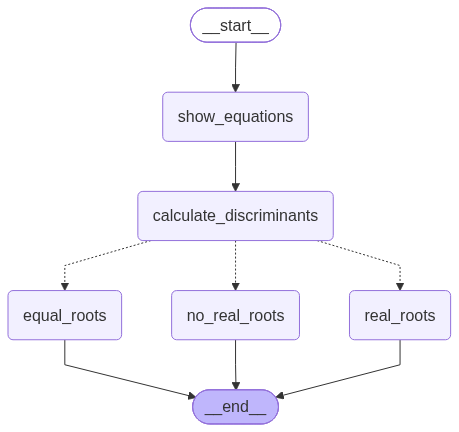

In [34]:
workflow

In [35]:
initial_state = {
    'a': 4,
    'b': 2,
    'c': 4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4x² + 2x + 4',
 'discriminant': -60,
 'result': 'The roots are imaginary. No real root exists'}